In [1]:
# Kütüphaneleri yüklüyoruz
%pip install tensorflow opencv-python mediapipe scikit-learn matplotlib pyttsx3 seaborn pydot pydotplus h5py

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# MediaPipe Modelleri
mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

# GÖRÜNTÜ İŞLEME VE ALGILAMA
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image.flags.writeable = False                  
    results = model.process(image)                 
    image.flags.writeable = True                   
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
    return image, results

# GÖRSELLEŞTİRME (ÇİZİM)
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)) 
    
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)) 
    
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)) 
    
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)) 


def extract_keypoints(results):
    """
    Sadece Pose (Vücut) ve Elleri alıyoruz. Yüz verisi iptal edildi.
    Toplam Boyut: 33*4 + 21*3 + 21*3 = 258
    """
    # 1. POSE
    if results.pose_landmarks:
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten()
    else:
        pose = np.zeros(33*4)
    
    # 2. SOL EL
    if results.left_hand_landmarks:
        lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten()
    else:
        lh = np.zeros(21*3)
        
    # 3. SAĞ EL
    if results.right_hand_landmarks:
        rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten()
    else:
        rh = np.zeros(21*3)
        
    # SADECE POSE + SOL EL + SAĞ EL
    return np.concatenate([pose, lh, rh])

In [2]:
import os
import numpy as np

# veri yolu
DATA_PATH = os.path.join('MP_Data') 

# olusacak kelime listesi
actions = np.array([
    'merhaba', 'gunaydin', 'nasilsin', 'iyiyim', 'tesekkurler',
    'gorusuruz', 'ben', 'sen', 'o', 'sevmek',
    'istemek', 'almak', 'vermek', 'gitmek', 'gelmek',
    'beklemek', 'anlamak', 'bilmek', 'calismak', 'okul',
    'ev', 'kahve', 'su', 'para', 'araba',
    'bugun', 'yarin', 'evet', 'hayir', 'simdi'
])

no_sequences = 60 # simdilik toplam video sayısı (her kelime için)
sequence_length = 45 # frame sayısı 

# MP_Data -> Kelime -> Video Numarası -> Frame Verileri (.npy)
# klasör olusturma
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)), exist_ok=True)
        except:
            pass

# print(f"Sistem şu mevcut klasörle test edilecek: {actions}")

In [ ]:
#  VERİ TOPLAMA KISMI 


cap = cv2.VideoCapture(0)


break_all = False 

# MediaPipe modelini başlat
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # KELIME DONGUSU
    for action in actions:
        if break_all: break 

        # VIDEO DONGUSU
        for sequence in range(no_sequences):
            if break_all: break 



            folder_path = os.path.join(DATA_PATH, action, str(sequence))
            

            if os.path.exists(folder_path) and len(os.listdir(folder_path)) >= sequence_length:
                print(f"⏩ {action} - Video {sequence} zaten var, atlanıyor...")
                continue 
            


            # HAZIRLIK ASAMASI
            while True:
                ret, frame = cap.read()
                image, results = mediapipe_detection(frame, holistic)
                draw_landmarks(image, results)
                
                # BILGILENDIRME
                cv2.putText(image, 'KAYIT: {} - Video No: {}'.format(action, sequence), (15,30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2, cv2.LINE_AA)
                cv2.putText(image, 'Baslamak icin SPACE tusuna bas', (50,250), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2, cv2.LINE_AA)
                
                cv2.imshow('OpenCV Feed', image)
                
                if cv2.waitKey(10) & 0xFF == ord(' '):
                    break
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break_all = True
                    break
            
            if break_all: break

            # GERI SAYIM
            start_time = time.time()
            while time.time() - start_time < 2: 
                ret, frame = cap.read()
                image, results = mediapipe_detection(frame, holistic)
                draw_landmarks(image, results)
                
                countdown = 2 - int(time.time() - start_time)
                cv2.putText(image, str(countdown), (280,250), 
                           cv2.FONT_HERSHEY_SIMPLEX, 3, (0,255,255), 5, cv2.LINE_AA)
                
                cv2.imshow('OpenCV Feed', image)
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break_all = True
                    break
            
            if break_all: break

            # KAYIT KISMI
            for frame_num in range(sequence_length):
                ret, frame = cap.read()
                image, results = mediapipe_detection(frame, holistic)
                draw_landmarks(image, results)
                
                cv2.putText(image, 'KAYITTA...', (15,30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2, cv2.LINE_AA)
                
                # Veriyi Kaydet (YENİ FONKSİYON İLE)
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                cv2.imshow('OpenCV Feed', image)

                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break_all = True
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

⏩ merhaba - Video 0 zaten var, atlanıyor...
⏩ merhaba - Video 1 zaten var, atlanıyor...
⏩ merhaba - Video 2 zaten var, atlanıyor...
⏩ merhaba - Video 3 zaten var, atlanıyor...
⏩ merhaba - Video 4 zaten var, atlanıyor...
⏩ merhaba - Video 5 zaten var, atlanıyor...
⏩ merhaba - Video 6 zaten var, atlanıyor...
⏩ merhaba - Video 7 zaten var, atlanıyor...
⏩ merhaba - Video 8 zaten var, atlanıyor...
⏩ merhaba - Video 9 zaten var, atlanıyor...
⏩ merhaba - Video 10 zaten var, atlanıyor...
⏩ merhaba - Video 11 zaten var, atlanıyor...
⏩ merhaba - Video 12 zaten var, atlanıyor...
⏩ merhaba - Video 13 zaten var, atlanıyor...
⏩ merhaba - Video 14 zaten var, atlanıyor...
⏩ merhaba - Video 15 zaten var, atlanıyor...
⏩ merhaba - Video 16 zaten var, atlanıyor...
⏩ merhaba - Video 17 zaten var, atlanıyor...
⏩ merhaba - Video 18 zaten var, atlanıyor...
⏩ merhaba - Video 19 zaten var, atlanıyor...
⏩ merhaba - Video 20 zaten var, atlanıyor...
⏩ merhaba - Video 21 zaten var, atlanıyor...
⏩ merhaba - Video 22

C:\Users\eray_\AppData\Local\Temp\ipykernel_22832\4019470158.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


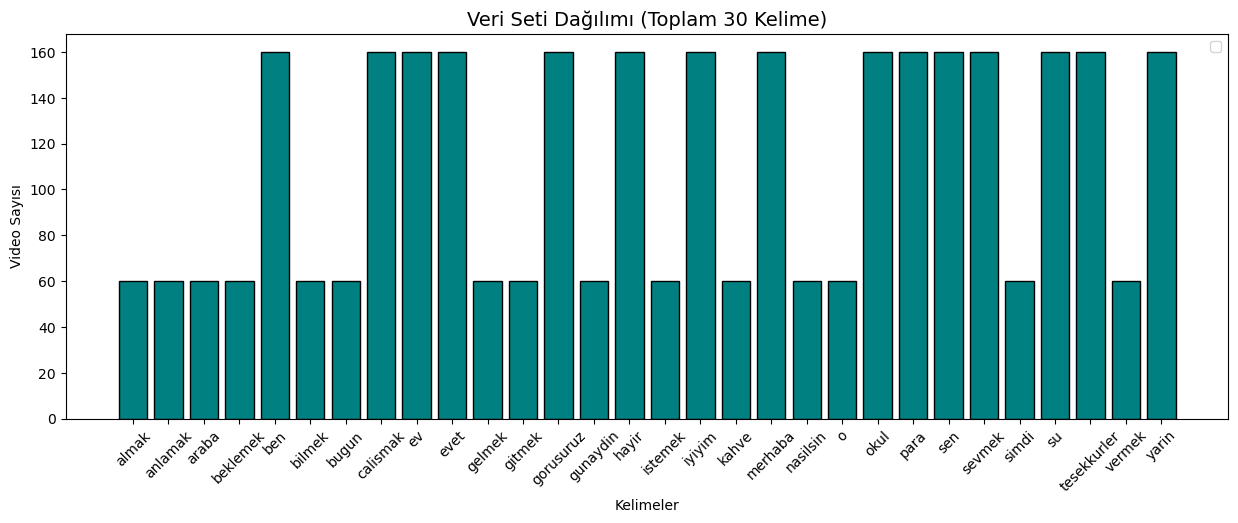

Toplam 3300 adet video verisi var.


In [ ]:
import matplotlib.pyplot as plt
import os

# GRAFIK KISIMI


# Verilerin olduğu klasör
DATA_PATH = os.path.join('MP_Data') 

def plot_data_distribution():
    
    # Kelimeleri ve video sayılarını tutacak boş listeler
    kelimeler = []
    sayilar = []
    
    # Klasörleri tek tek gezer
    if os.path.exists(DATA_PATH):
        for klasor_adi in os.listdir(DATA_PATH):
            tam_yol = os.path.join(DATA_PATH, klasor_adi)
            
            if os.path.isdir(tam_yol):
                dosya_sayisi = len(os.listdir(tam_yol))
                
                kelimeler.append(klasor_adi) # Kelimeyi listeye ekle
                sayilar.append(dosya_sayisi) # Sayısını listeye ekle
    
    # GRAFİK
    plt.figure(figsize=(15, 5))
    
    # Çubuk grafiği çizdir
    plt.bar(kelimeler, sayilar, color='teal', edgecolor='black')
    
    # Başlıklar
    plt.title(f'Veri Seti Dağılımı (Toplam {len(kelimeler)} Kelime)', fontsize=14)
    plt.xlabel('Kelimeler')
    plt.ylabel('Video Sayısı')
    
    
    # Alt yazılar birbirine girmesin
    plt.xticks(rotation=45)
    
    # Bilgi kutusunu göster
    plt.legend()
    
    # Grafiği göster
    plt.show()
    
    print(f"Toplam {sum(sayilar)} adet video verisi var.")

# Fonksiyonu çalıştır
plot_data_distribution()

📦 Veriler diskten taranıyor... (Biraz sabır)
   -> merhaba: 160 video yüklendi.
   -> gunaydin: 60 video yüklendi.
   -> nasilsin: 60 video yüklendi.
   -> iyiyim: 160 video yüklendi.
   -> tesekkurler: 160 video yüklendi.
   -> gorusuruz: 160 video yüklendi.
   -> ben: 160 video yüklendi.
   -> sen: 160 video yüklendi.
   -> o: 60 video yüklendi.
   -> sevmek: 160 video yüklendi.
   -> istemek: 60 video yüklendi.
   -> almak: 60 video yüklendi.
   -> vermek: 60 video yüklendi.
   -> gitmek: 60 video yüklendi.
   -> gelmek: 60 video yüklendi.
   -> beklemek: 60 video yüklendi.
   -> anlamak: 60 video yüklendi.
   -> bilmek: 60 video yüklendi.
   -> calismak: 160 video yüklendi.
   -> okul: 160 video yüklendi.
   -> ev: 160 video yüklendi.
   -> kahve: 60 video yüklendi.
   -> su: 160 video yüklendi.
   -> para: 160 video yüklendi.
   -> araba: 60 video yüklendi.
   -> bugun: 60 video yüklendi.
   -> yarin: 160 video yüklendi.
   -> evet: 160 video yüklendi.
   -> hayir: 160 video yükle

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 45, 128)        │       165,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 45, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,598 (1.35 MB)

 Trainable params: 353,598 (1.35 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Eğitim Başlıyor... Arkana yaslan!
Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - categorical_accuracy: 0.0504 - loss: 3.3427
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.0701 - loss: 3.0903
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - categorical_accuracy: 0.0939 - loss: 2.8493
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.1205 - loss: 2.6537
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - categorical_accuracy: 0.1473 - loss: 2.4944
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.1735 - loss: 2.3217
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.1788 - loss: 2.2237
Epoch 8/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.1833 - loss: 2.2073
Epoch 9/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - categorical_accuracy: 0.2110 - loss: 2.0400
Epoch 10/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - categorical_accuracy: 0.21


🎉 TEBRİKLER! Model 'action.h5' olarak kaydedildi.
📊 Eğitim grafikleri 'egitim_grafikleri.png' olarak kaydedildi.


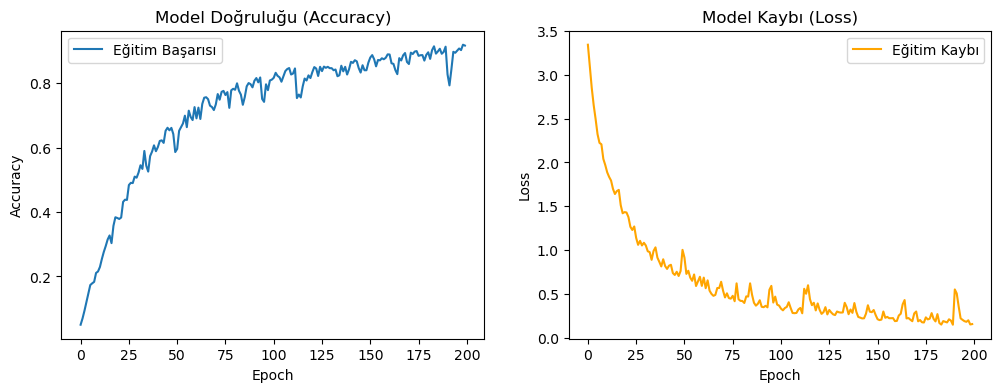

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Input, Dropout
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np
import os
import matplotlib.pyplot as plt


# 1. AYARLAR VE VERİ SETİ TANIMI

DATA_PATH = os.path.join('MP_Data') 


actions = np.array([
    'merhaba', 'gunaydin', 'nasilsin', 'iyiyim', 'tesekkurler',
    'gorusuruz', 'ben', 'sen', 'o', 'sevmek',
    'istemek', 'almak', 'vermek', 'gitmek', 'gelmek',
    'beklemek', 'anlamak', 'bilmek', 'calismak', 'okul',
    'ev', 'kahve', 'su', 'para', 'araba',
    'bugun', 'yarin', 'evet', 'hayir', 'simdi'
])

sequence_length = 45


label_map = {label:num for num, label in enumerate(actions)}

sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    
    if not os.path.exists(action_path):
        print(f"{action} klasörü yok.")
        continue
    
    # Klasör içindeki tüm videoları listeleme
    video_list = [x for x in os.listdir(action_path) if os.path.isdir(os.path.join(action_path, x))]
    
    count = 0
    for sequence in video_list:
        window = []
        try:
            # 45 kareyi tek tek oku
            for frame_num in range(sequence_length):
                res_path = os.path.join(action_path, sequence, "{}.npy".format(frame_num))
                res = np.load(res_path)
                window.append(res)
            
            # Eksik kare yoksa listeye ekle
            if len(window) == sequence_length:
                sequences.append(window)
                labels.append(label_map[action])
                count += 1
        except Exception as e:
            pass # Bozuk dosya varsa atla

    print(f"   -> {action}: {count} video yüklendi.")

print(f"\n TOPLAM EĞİTİM VERİSİ: {len(sequences)}")

# Veriyi Hazırla
X = np.array(sequences)
y = to_categorical(labels).astype(int)

# Eğitim/Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y)

# CLASS WEIGHTS (Dengeleme)
y_integers = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_integers), 
    y=y_integers
)
class_weights_dict = dict(enumerate(class_weights))
print("Ağırlıklar dengelendi.")


# 3. MODEL MİMARİSİ (Bi-LSTM + Dropout)
model = Sequential()

# Giriş
model.add(Input(shape=(sequence_length, 258)))

# Katman 1: Bi-LSTM
model.add(Bidirectional(LSTM(64, return_sequences=True, activation='tanh')))
model.add(Dropout(0.5)) 

# Katman 2
model.add(LSTM(128, return_sequences=True, activation='tanh'))
model.add(Dropout(0.5)) 

# Katman 3: Son LSTM
model.add(LSTM(64, return_sequences=False, activation='tanh'))
model.add(Dropout(0.5)) 

# Karar Katmanları
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Çıktı
model.add(Dense(actions.shape[0], activation='softmax'))

# Derleme
opt = Adam(learning_rate=0.0005) 
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

model.summary()


# 4. EĞİTİMİ BAŞLAT
print("\n Eğitim Başlıyor...")

# Log klasörü
log_dir = os.path.join('Training_Logs_Dropout')
tb_callback = TensorBoard(log_dir=log_dir)


history = model.fit(X_train, y_train, 
                    epochs=200, 
                    callbacks=[tb_callback], 
                    class_weight=class_weights_dict) 


# 5. KAYDET VE RAPORLA
model.save('action.h5') 
print("\n Model 'action.h5' olarak kaydedildi.")

# Grafikleri Çiz ve Kaydet (Tez Raporu İçin)
try:
    plt.figure(figsize=(12, 4))
    
    # Accuracy Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Eğitim Başarısı')
    plt.title('Model Doğruluğu (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı', color='orange')
    plt.title('Model Kaybı (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.savefig('egitim_grafikleri.png')
    print(" Kaydedildi")
    plt.show()
except:
    print("HATA")